# 02 - Reading Pulses And Making First Plots

Now we turn Physics frames into ordinary Python rows.

This lets us turn IceTray objects into Python-friendly objects so we can use tools like Pandas and Matplotlib on the data.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from icecube import dataio, dataclasses

SIM_FILE = Path('/data/sim/IceCube/2020/filtered/level2/CORSIKA-in-ice/20904/0000000-0000999/Level2_IC86.2020_corsika.020904.000000.i3.zst')
DATA_FILE = Path('/data/exp/IceCube/2020/filtered/level2/0101/Run00133576/Level2_IC86.2019_data_Run00133576_Subrun00000000_00000000.i3.zst')

print('Experimental data file exists:', DATA_FILE.exists())
print('Simulation file exists:       ', SIM_FILE.exists())


Experimental data file exists: True
Simulation file exists:        True


## Small helper functions

These are some common-use functions.

A pulse map is typically stored under a key like `SplitInIcePulses`. The exact key can change between files, so we try a short list of common possibilities.


In [9]:
def frame_stop(frame):
    names = {'Q': 'DAQ', 'P': 'Physics', 'G': 'Geometry', 'C': 'Calibration', 'D': 'DetectorStatus', 'I': 'TrayInfo'}
    return names.get(str(frame.Stop), str(frame.Stop))

def event_header_as_dict(frame):
    if 'I3EventHeader' not in frame:
        return {}
    header = frame['I3EventHeader']
    return {
        'run_id': header.run_id,
        'event_id': header.event_id,
        'sub_event_id': header.sub_event_id,
        'sub_event_stream': str(header.sub_event_stream),
    }

def find_pulse_key(frame):
    possible_keys = ['SplitInIcePulses', 'SplitInIceDSTPulses', 'SRTInIcePulses', 'InIcePulses', 'OfflinePulses']
    for key in possible_keys:
        if key in frame:
            return key
    return None

def summarize_pulses(frame):
    pulse_key = find_pulse_key(frame)
    if pulse_key is None:
        return None

    # from_frame works for regular pulse maps and for common pulse masks.
    pulse_map = dataclasses.I3RecoPulseSeriesMap.from_frame(frame, pulse_key)

    hit_doms = 0
    number_of_pulses = 0
    total_charge = 0.0

    for omkey, pulses_on_one_dom in pulse_map:
        hit_doms += 1
        number_of_pulses += len(pulses_on_one_dom)
        for pulse in pulses_on_one_dom:
            total_charge += pulse.charge  # <--- Notice how we find the total charge... you sum all the charge depisited in each DOM.
                                          #      1 waveform = charge deposited over time over full event window for 1 DOM. 1 pulse = a clear signal/hit extracted from that waveform.

    return {
        'pulse_key': pulse_key,
        'hit_doms': hit_doms,
        'number_of_pulses': number_of_pulses,
        'total_charge': total_charge,
    }


## Optional: get a simple reconstructed direction

This Level2 file contains several reconstructed particles.

A reconstructed particle (often) has a direction with zenith and azimuth angles. Not all have energy estimates. None will have mass estimates.

We try a few common keys and keep the first one that exists.


In [13]:
def reconstruction_as_dict(frame):
    possible_reco_keys = ['SplineMPE', 'MPEFit', 'LineFit', 'OnlineL2_SplineMPE']
    for key in possible_reco_keys:
        if key in frame:
            particle = frame[key]
            return {
                'reco_key': key,
                'zenith_rad': float(particle.dir.zenith),
                'azimuth_rad': float(particle.dir.azimuth),
                'energy_GeV': float(getattr(particle, 'energy', float('nan'))),
            }
    return {'reco_key': None, 'zenith_rad': float('nan'), 'azimuth_rad': float('nan'), 'energy_GeV': float('nan')}

print('Defined a helper that looks for a few common reconstruction keys.')


Defined a helper that looks for a few common reconstruction keys.


## Build an event table

Now loop over P-frames.

For each P-frame, create a normal Python dictionary.

At the end, Pandas turns the list of dictionaries into a table.


In [20]:
def build_event_table(i3_path, max_physics_frames=500):
    rows = []
    physics_frames_seen = 0
    frames_with_pulses = 0

    i3_file = dataio.I3File(str(i3_path))
    while i3_file.more() and physics_frames_seen < max_physics_frames:
        frame = i3_file.pop_frame()
        if frame_stop(frame) != 'Physics':
            continue

        physics_frames_seen += 1
        row = event_header_as_dict(frame)

        pulse_summary = summarize_pulses(frame)
        if pulse_summary is not None:
            frames_with_pulses += 1
            row.update(pulse_summary)

        row.update(reconstruction_as_dict(frame))
        rows.append(row)

    i3_file.close()

    print(f'Read {physics_frames_seen} Physics frames from {i3_path.name}.')
    print(f'Frames with a recognized pulse key: {frames_with_pulses}')
    return pd.DataFrame(rows)

data_events = build_event_table(DATA_FILE, max_physics_frames=500)
print('Columns in the table:', list(data_events.columns))
# data_events.head()
data_events.head(20)


Read 500 Physics frames from Level2_IC86.2019_data_Run00133576_Subrun00000000_00000000.i3.zst.
Frames with a recognized pulse key: 500
Columns in the table: ['run_id', 'event_id', 'sub_event_id', 'sub_event_stream', 'pulse_key', 'hit_doms', 'number_of_pulses', 'total_charge', 'reco_key', 'zenith_rad', 'azimuth_rad', 'energy_GeV']


,run_id,event_id,sub_event_id,sub_event_stream,pulse_key,hit_doms,number_of_pulses,total_charge,reco_key,zenith_rad,azimuth_rad,energy_GeV
0,133576,2061,0,NullSplit,InIcePulses,56,75,71.517496,None,NaN,NaN,NaN
1,133576,2061,0,InIceSplit,SplitInIcePulses,56,75,71.517496,MPEFit,2.275125,5.371176,NaN
2,133576,2062,0,NullSplit,InIcePulses,58,63,54.175000,None,NaN,NaN,NaN
3,133576,2062,0,InIceSplit,SplitInIcePulses,57,62,53.300000,LineFit,0.375475,1.600200,NaN
4,133576,2065,0,IceTopSplit,InIcePulses,221,548,493.117124,None,NaN,NaN,NaN
5,133576,2065,0,NullSplit,InIcePulses,221,548,493.117124,None,NaN,NaN,NaN
6,133576,2065,0,InIceSplit,SplitInIcePulses,195,513,457.692124,None,NaN,NaN,NaN
7,133576,2073,0,NullSplit,InIcePulses,64,81,83.125000,None,NaN,NaN,NaN
8,133576,2073,0,InIceSplit,SplitInIcePulses,63,80,82.000000,LineFit,0.672902,3.617338,NaN
9,133576,2075,0,NullSplit,InIcePulses,43,55,62.275000,None,NaN,NaN,NaN


## Plot hit DOMs and charge

A DOM counts as hit if it has at least one pulse in the pulse map.

Total charge is a rough event-size variable: bigger events tend to have more charge.


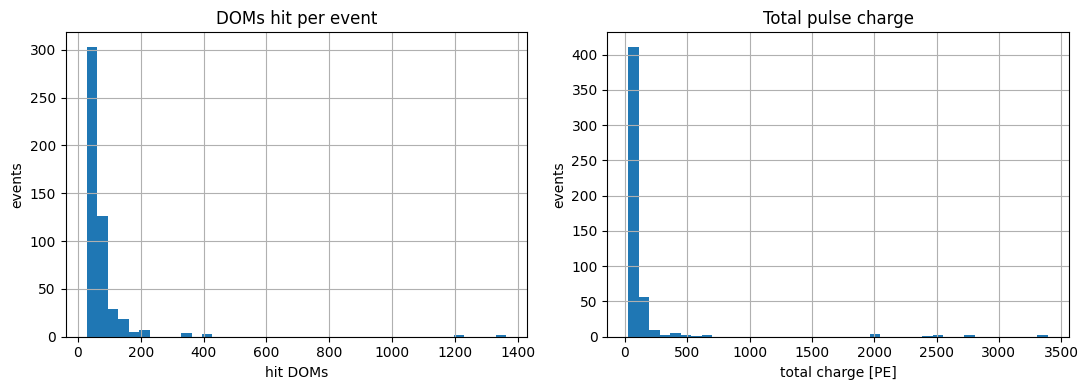

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

data_events['hit_doms'].dropna().hist(ax=axes[0], bins=40)
axes[0].set_xlabel('hit DOMs')
axes[0].set_ylabel('events')
axes[0].set_title('DOMs hit per event')

data_events['total_charge'].dropna().hist(ax=axes[1], bins=40)
axes[1].set_xlabel('total charge [PE]')
axes[1].set_ylabel('events')
axes[1].set_title('Total pulse charge')

plt.tight_layout()


## Compare experimental data to simulation

This isn't a proper comparison. Simulated events are generated with a different energy spectrum than real data.

But, it's good to see that the code works the same way for both files.

Read 500 Physics frames from Level2_IC86.2020_corsika.020904.000000.i3.zst.
Frames with a recognized pulse key: 500


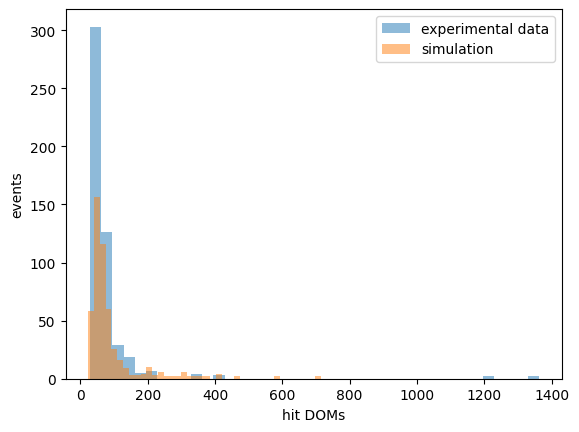

In [28]:
sim_events = build_event_table(SIM_FILE, max_physics_frames=500)

ax = data_events['hit_doms'].dropna().plot.hist(bins=40, alpha=0.5, label='experimental data')
sim_events['hit_doms'].dropna().plot.hist(ax=ax, bins=40, alpha=0.5, label='simulation')
ax.set_xlabel('hit DOMs')
ax.set_ylabel('events')
ax.legend()
plt.show()

## Practice

1. Add a new table column for zenith in degrees instead of radians.
2. Make a histogram of some of the other objects seen in the table (zenith, azimuth, total charge).
    1) Add more events to the histogram.
    2) Change the bin number.


Read 2000 Physics frames from Level2_IC86.2019_data_Run00133576_Subrun00000000_00000000.i3.zst.
Frames with a recognized pulse key: 2000
Read 2000 Physics frames from Level2_IC86.2020_corsika.020904.000000.i3.zst.
Frames with a recognized pulse key: 2000


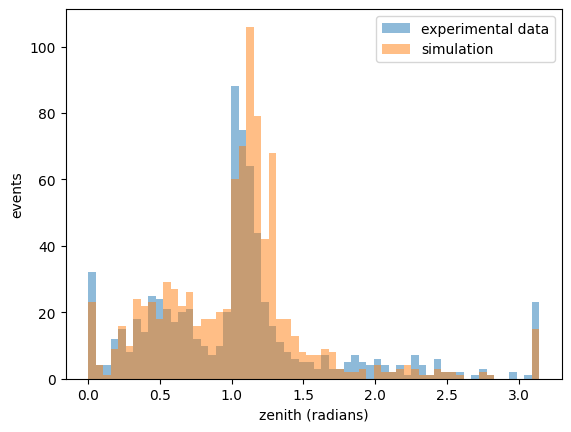

In [31]:
data_events = build_event_table(DATA_FILE, max_physics_frames=2000)
sim_events = build_event_table(SIM_FILE, max_physics_frames=2000)


ax = data_events['zenith_rad'].dropna().plot.hist(bins=60, alpha=0.5, label='experimental data')
sim_events['zenith_rad'].dropna().plot.hist(ax=ax, bins=60, alpha=0.5, label='simulation')
ax.set_xlabel('zenith (radians)')
ax.set_ylabel('events')
ax.legend()
plt.show()